# Import Liabraries

In [76]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

# Data Gathering

In [77]:
df = pd.read_csv("Telco-Customer-churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Phase 1. Understanding Data

In [78]:
df.shape

(7043, 21)

In [79]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [80]:
# Here we notice that the column TotalCharges data-type 
# is Object so we have to convert it into numeric and after 

In [81]:
# here we convert our column into numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [82]:
# after converting the column d-type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [83]:
# checking null values
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [84]:
# checking duplicates
df.duplicated().sum()

np.int64(0)

In [85]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Droping Null values

In [86]:
# TotalCharges column me sirf 11 null values the jo ki dataset 
# ka bhut chota hissa thi missingness ka impact neligible tha 
# esliye data quality bnaye rakhne ke liye un rows ko remove kar diya
df = df.dropna(subset=['TotalCharges'])

In [87]:
df.shape

(7032, 21)

### Checking Unique Customer

In [88]:
df['customerID'].nunique()

7032

In [89]:
# so,total number of unique customer is 7032 and 21 attributes

# Phase 2. EDA(Exploratry Data Analysis)

### Univariate Analysis

In [90]:
# Count churn values
churn_counts = df['Churn'].value_counts()

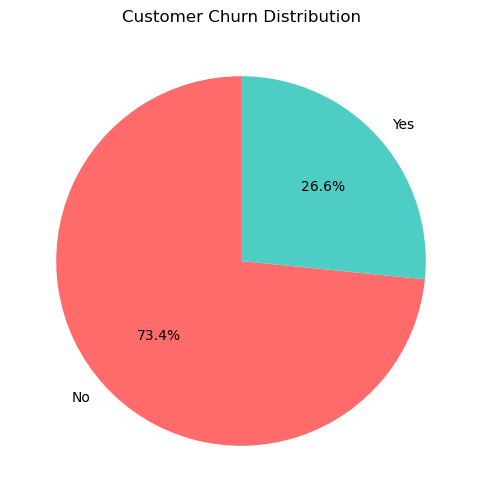

In [91]:
#1. Churn Distribution
plt.figure(figsize=(10,6))
plt.pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff6b6b', '#4ecdc4'])
plt.title('Customer Churn Distribution')
plt.show()

In [92]:
# After analyzing this visuals the Insight is:
    # Most of the customers are retained 
    # while around some customers are churned.

In [93]:
gender_counts = df['gender'].value_counts()

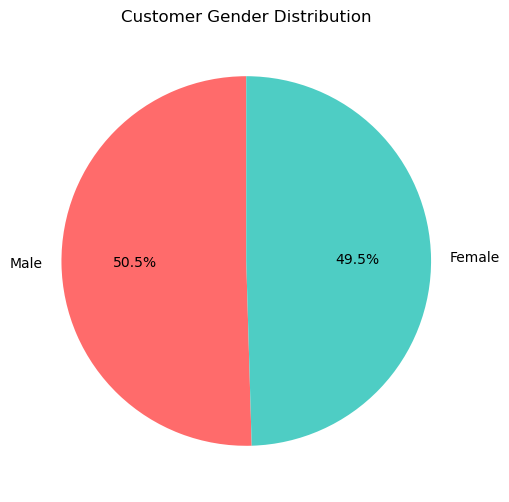

In [94]:
#2. Gender Distribution
plt.figure(figsize=(10,6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=['#ff6b6b', '#4ecdc4'])
plt.title('Customer Gender Distribution')
plt.show()

In [95]:
# After analyzing this visuals the Insight is:
    # The gender distribution is almost equal, 
    # but males hold a slight lead.

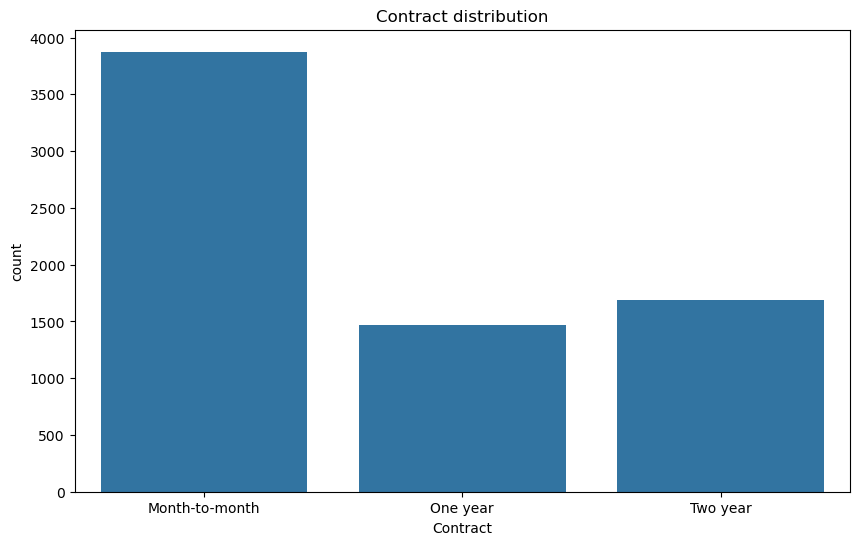

In [96]:
#3. Contract Distribution
plt.figure(figsize=(10,6))
sns.countplot(x='Contract', data=df)
plt.title("Contract distribution")
plt.show()

In [97]:
# After analyzing this visuals the Insight is:
    # customers are more delighted to take Monthly contract
    # on the other hands one-year and two-year contracts are taken by less customers 

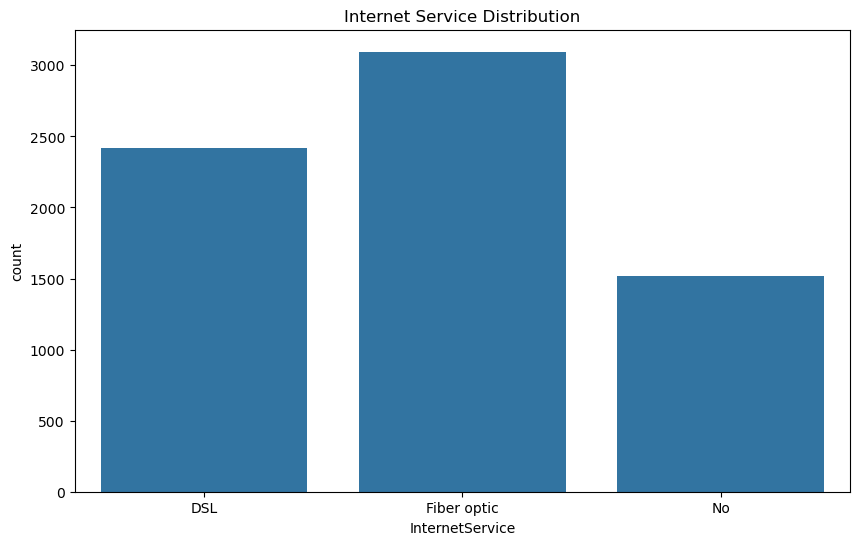

In [98]:
#4. InternetService Distribution
plt.figure(figsize=(10,6))
sns.countplot(x='InternetService', data=df)
plt.title("Internet Service Distribution")
plt.show()

In [99]:
# After analyzing this visuals the Insight is:
    # The fiber optic internetservice is used more than DSL
    # And also there are around 1500 customer who are not using any InternetService

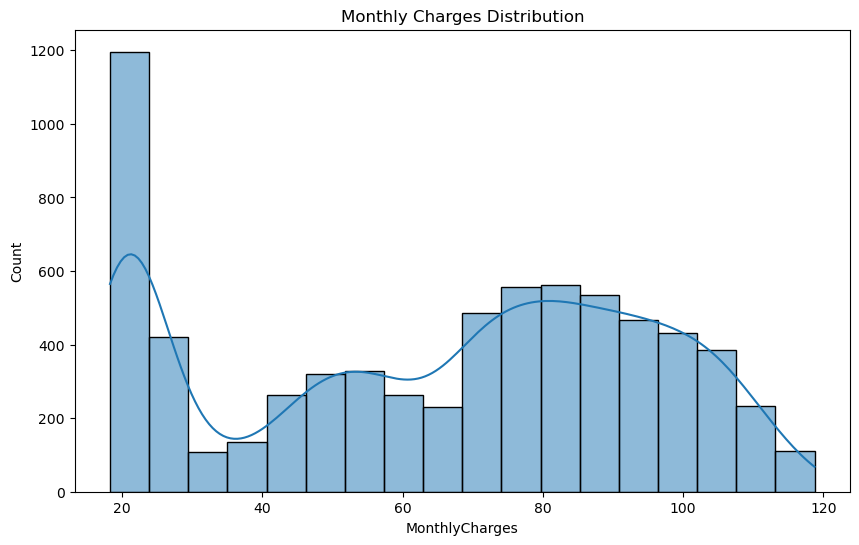

In [100]:
#5. Monthly Charges Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()

In [101]:
# After analyzing this visuals the Insight is:
    # Most of the customers have low Monthly Charges
    # number of customers with monthly charges between 75 and 100 is also high.
    # The average Monthly Charges is 64.8

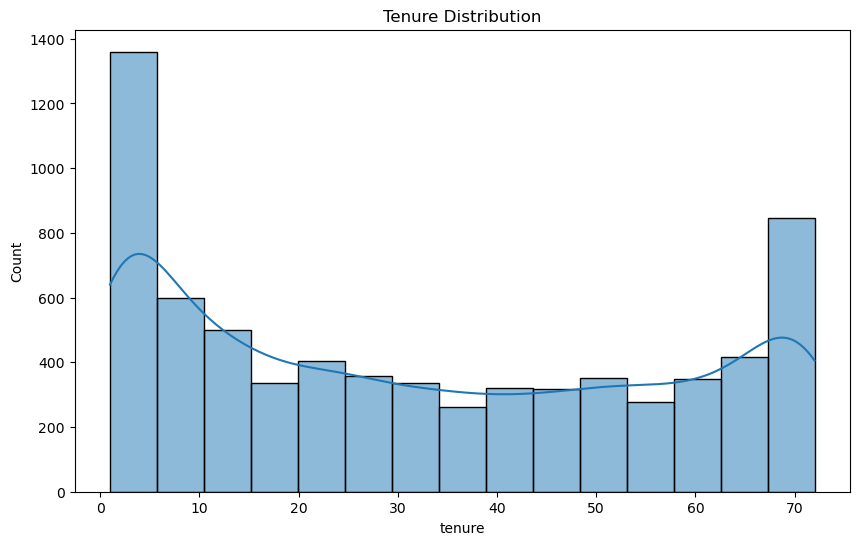

In [102]:
#6. Tenure Distribution
plt.figure(figsize=(10,6))
sns.histplot(df['tenure'], kde=True)
plt.title("Tenure Distribution")
plt.show()

In [103]:
# After analyzing this visuals the Insight is:
    # A large number of customers have very low tenure (0–5 months).
    # A large number of customers also have very high tenure (65–72 months).
    # The Distribution has two peaks first is at the start and the second is at the end. 

### Bivariate Analysis

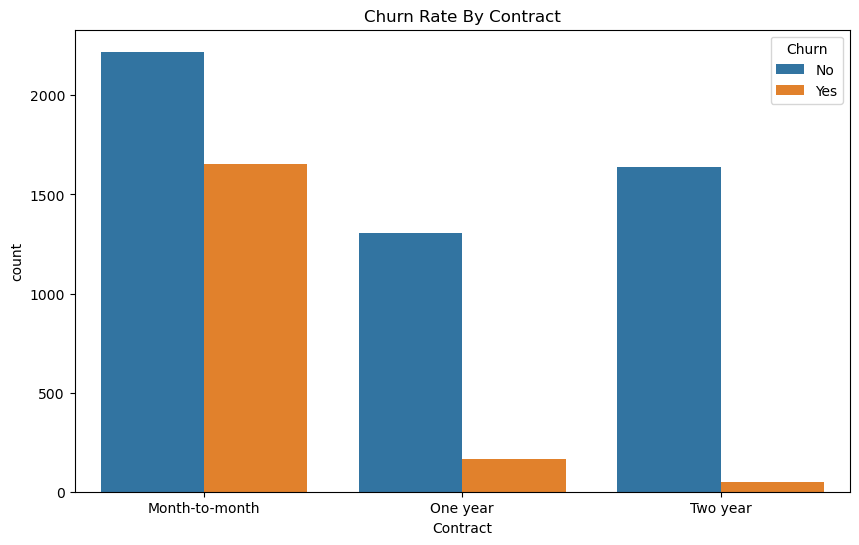

In [104]:
#1. Contract Vs Churn
plt.figure(figsize=(10,6))
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title("Churn Rate By Contract")
plt.show()

In [105]:
# After analyzing this visuals the Insight is:
    # Monthly customers churn is high.
    # On the other hand, customers with yearly or two-year contracts churn less.

In [106]:
round(pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100,2)

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


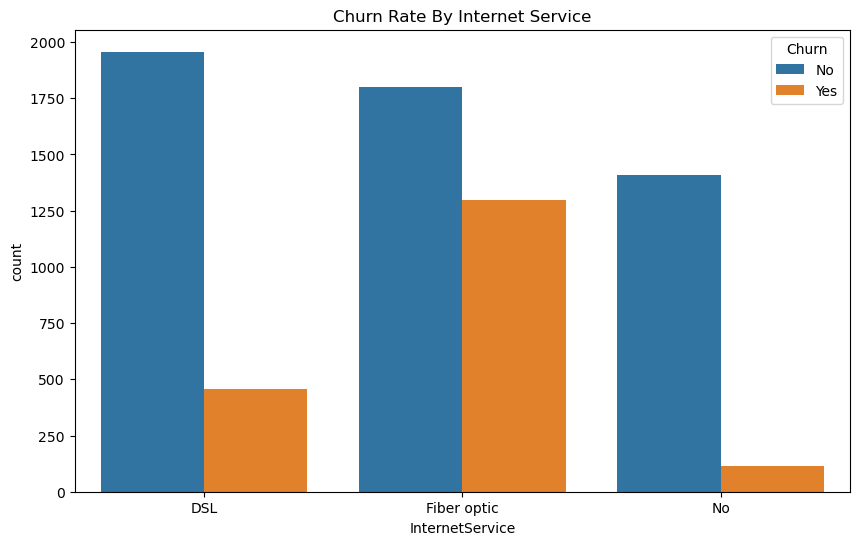

In [107]:
#2. Internet Service Vs Churn
plt.figure(figsize=(10,6))
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn Rate By Internet Service")
plt.show()

In [108]:
# After analyzing this visuals the Insight is:
    # Customers with Fiber Optic internet service have a high churn rate.
    # Customers with no internet service have the lowest churn rate.

In [109]:
round(pd.crosstab(df['InternetService'], df['Churn'], normalize='index')*100,2)

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


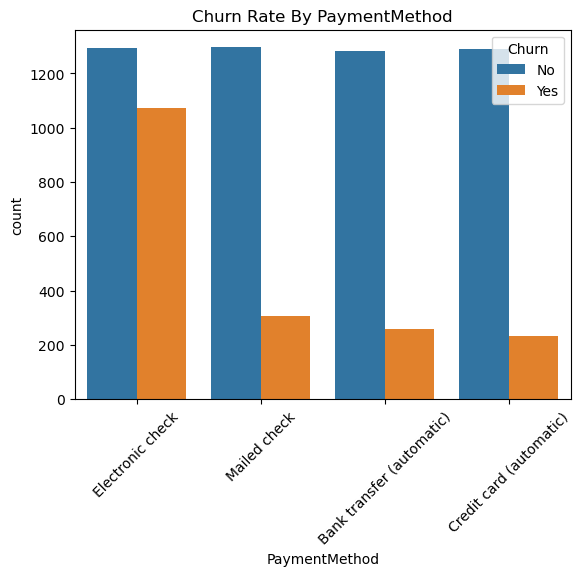

In [110]:
#3. Payment Method Vs Churn
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title("Churn Rate By PaymentMethod")
plt.xticks(rotation=45)
plt.show()

In [111]:
# After analyzing this visuals the Insight is:
    # Customers whose payment method is Electronic Check have a 
    # higher churn rate than customers using other payment methods.

In [112]:
round(pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')*100,2)

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


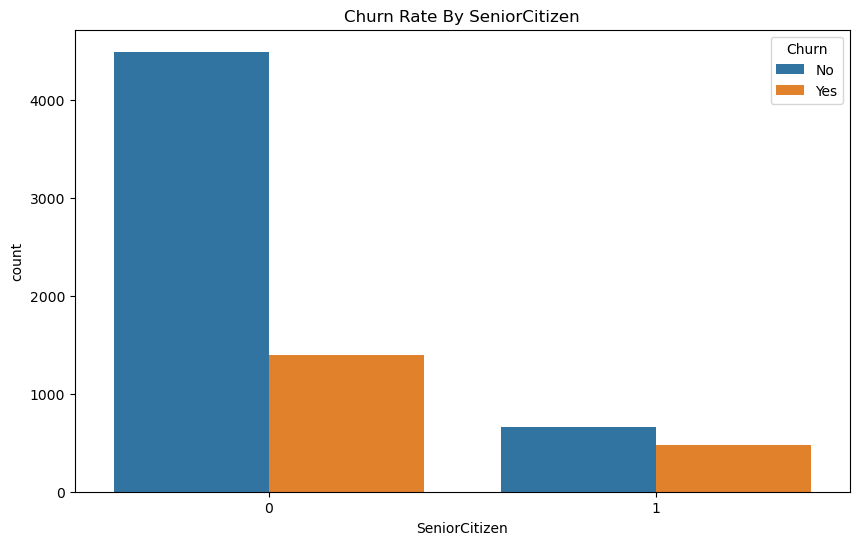

In [113]:
#4. Senior Citizen vs Churn
plt.figure(figsize=(10,6))
sns.countplot(x='SeniorCitizen',hue='Churn',data=df)
plt.title("Churn Rate By SeniorCitizen")
plt.show()

In [114]:
# After analyzing this visuals the Insight is:
    # SeniorCitizen has high churn rate 

In [115]:
round(pd.crosstab(df['SeniorCitizen'],df['Churn'],normalize='index')*100,2)

Churn,No,Yes
SeniorCitizen,,
0,76.35,23.65
1,58.32,41.68


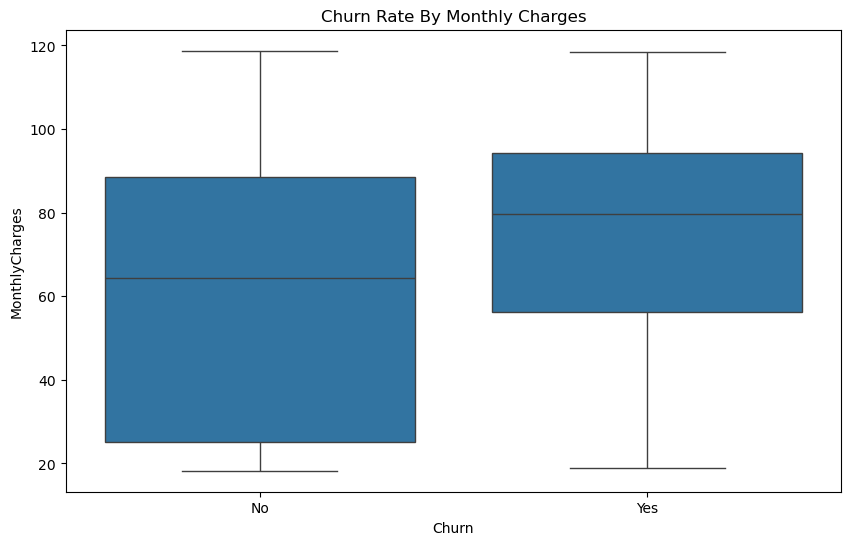

In [116]:
#5. Monthly Charges vs Churn
plt.figure(figsize=(10,6))
sns.boxplot(y="MonthlyCharges", x="Churn", data=df)
plt.title("Churn Rate By Monthly Charges")
plt.show()

In [117]:
atc = df.groupby('Churn')['MonthlyCharges'].mean()
print("Average Monthly Charges on the Basis of Churn is:-\n",atc)

Average Monthly Charges on the Basis of Churn is:-
 Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64


In [118]:
# After analyzing this visuals the Insight is:
    # Customers with higher monthly charges are more likely to churn.
    # The distributions are similar in spread, but churned customers have a higher median monthly charge.

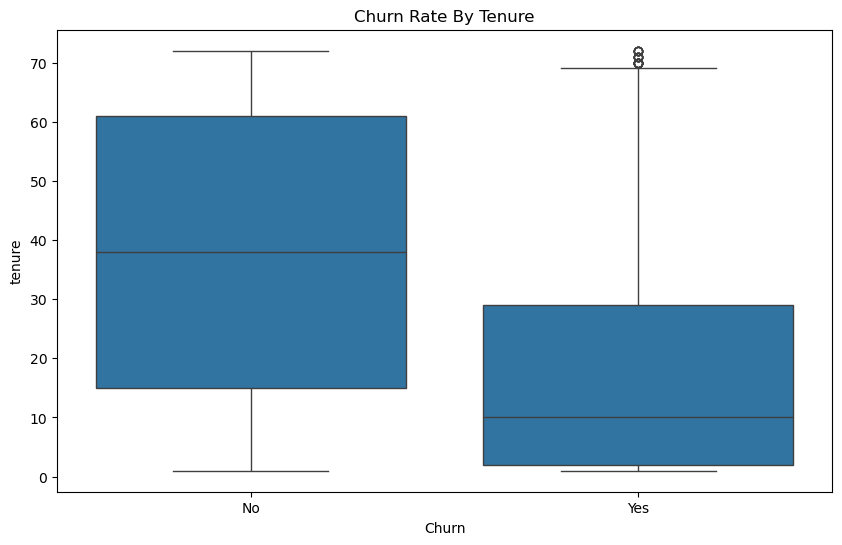

In [119]:
#6. Tenure vs Churn
plt.figure(figsize=(10,6))
sns.boxplot(x='Churn',y='tenure',data=df)
plt.title("Churn Rate By Tenure")
plt.show()

In [120]:
atc = df.groupby('Churn')['tenure'].mean()
print("Average Tenure on the Basis of Churn is:-\n",atc)

Average Tenure on the Basis of Churn is:-
 Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64


In [121]:
# After analyzing this visuals the Insight is:
    # Customers with lower tenure have a higher churn rate.
    # The average tenure of non-churned customers is 37 months.
    # The average tenure of churned customers is 17 Months

### Multivariate analysis

<Figure size 1000x600 with 0 Axes>

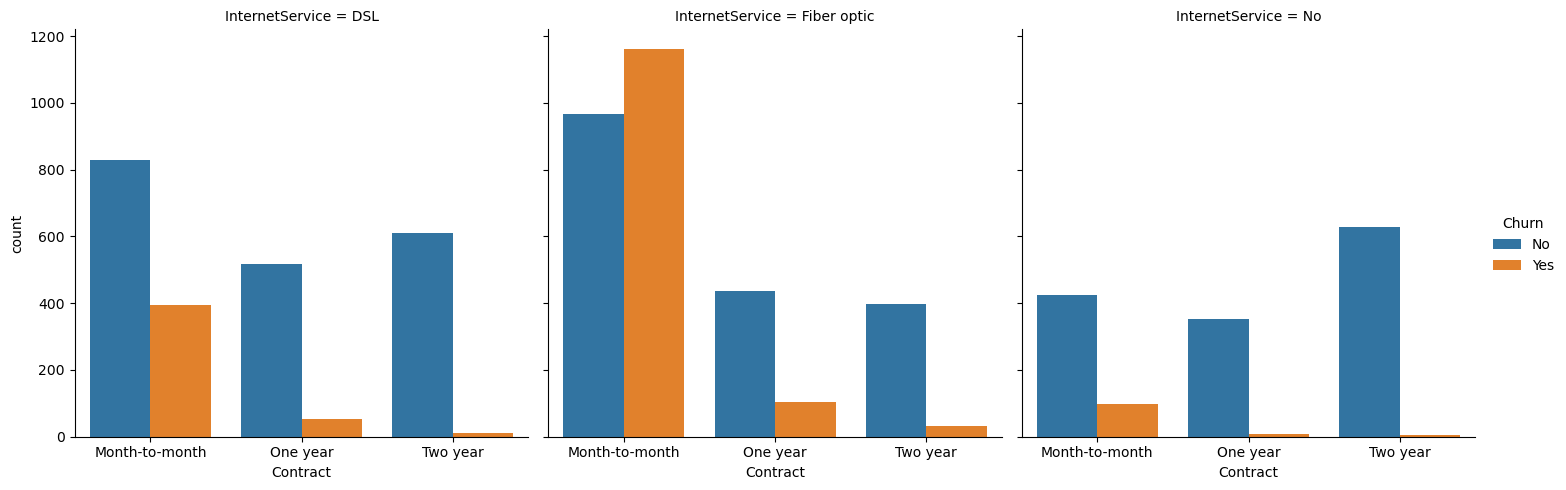

In [122]:
#1. Contract + Internet Service + Churn
plt.figure(figsize=(10,6))
sns.catplot(data=df, x='Contract', hue='Churn', col='InternetService', kind='count', height=5)
plt.show()

In [123]:
# After analyzing this visuals the Insight is:
    # The Month-to-Month customer from all the Internet Services have the high churn rate.
        # especially the customers who are using fiber-optic internet 
        # services have the highest churn rate in month-to-month contract.
    # Customers with two-year contracts have the lowest churn rate across all Internet Service categories.

<Figure size 1000x600 with 0 Axes>

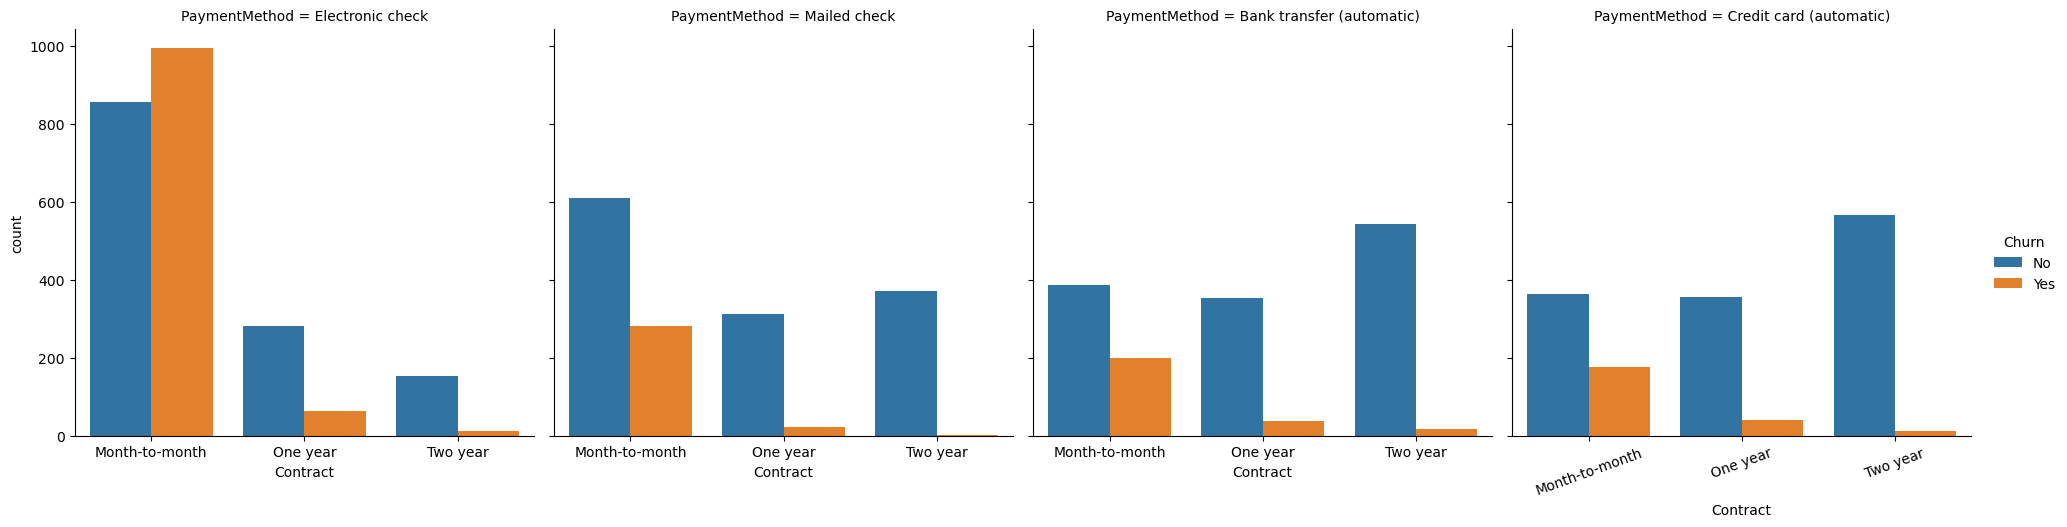

In [124]:
#2. Contract + Payment Method + Churn
plt.figure(figsize=(10,6))
sns.catplot(data=df,x='Contract',hue='Churn', col='PaymentMethod', kind='count')
plt.xticks(rotation=20)
plt.show()

In [125]:
# After analyzing this visuals the Insight is:
    # The Month-to-Month customer from all the Payment Method categories have the high churn rate.
        # especially the month-to-month customers whose payment
        # method is electronic check have the highest churn rate.  
    # Customers with two-year contracts have the lowest churn rate across all Payment Method categories.

<Figure size 1000x600 with 0 Axes>

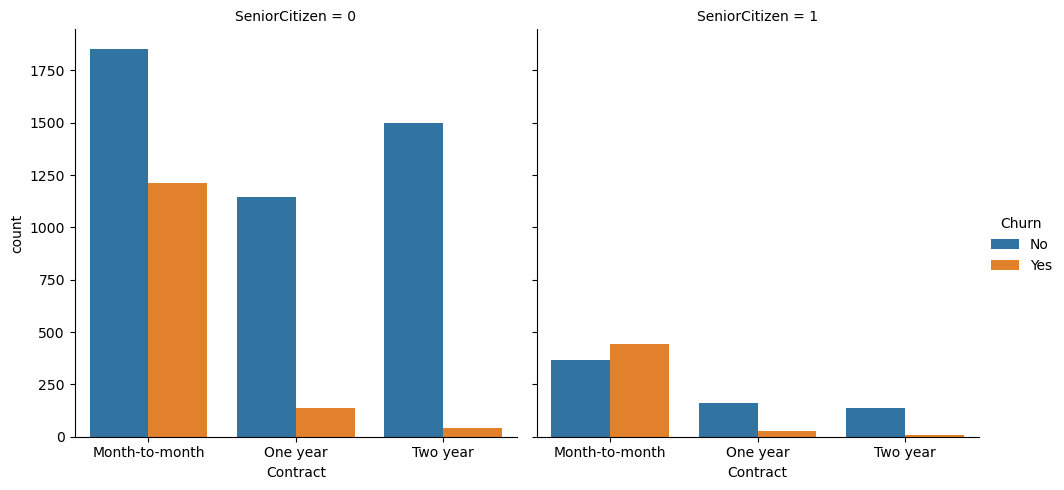

In [126]:
#3. senior Citizen + Contract + Churn
plt.figure(figsize=(10,6))
sns.catplot(data=df, x='Contract', hue='Churn', col='SeniorCitizen', kind='count', height=5)
plt.show()

In [127]:
# After analyzing this visuals the Insight is:
    # The Senior Citizen with Month-to-Month contracts have the high churn rate.
    # The Senior Citizen with two-year contracts have the lowest churn rate.

<Figure size 1000x600 with 0 Axes>

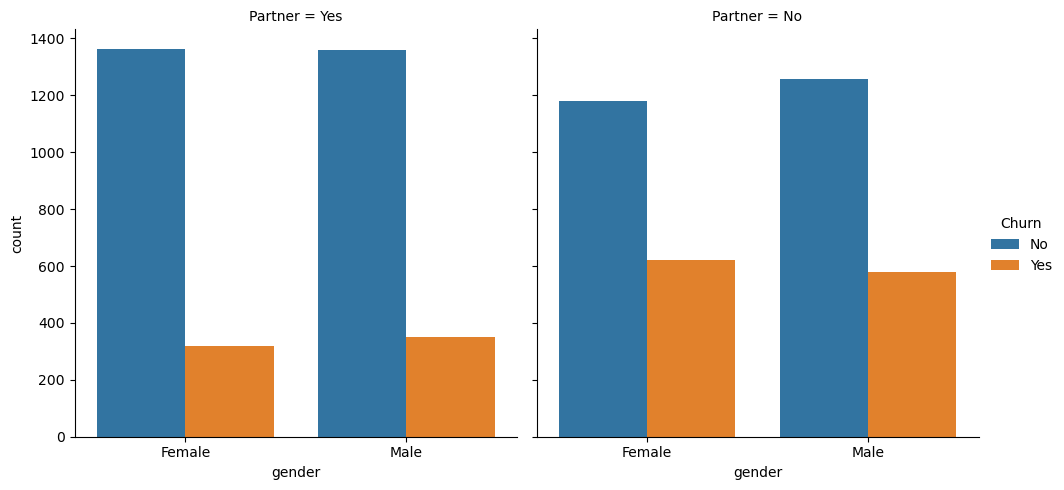

In [128]:
#4. Gender + Partner + Churn
plt.figure(figsize=(10,6))
sns.catplot(data=df, x='gender', hue='Churn', col='Partner', kind='count', height=5)
plt.show()

In [129]:
# After analyzing this visuals the Insight is:
    # The customer with no partners have high churn rate in 
    # both male and female categories comparatevily.

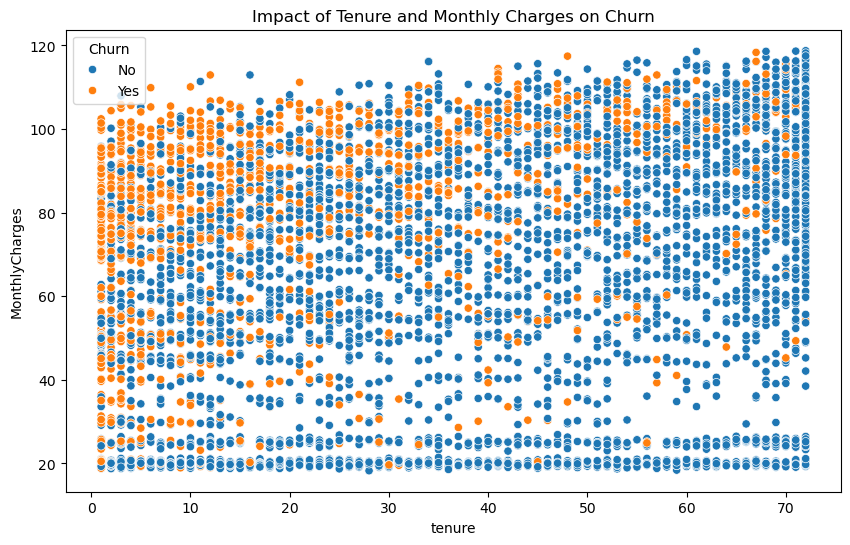

In [130]:
#5. Tenure + Monthly Charges + Churn
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn')
plt.title("Impact of Tenure and Monthly Charges on Churn")
plt.show()

In [131]:
# After analyzing this visuals the Insight is:
    # Customers with shorter tenure and higher monthly charges are more likely to churn.

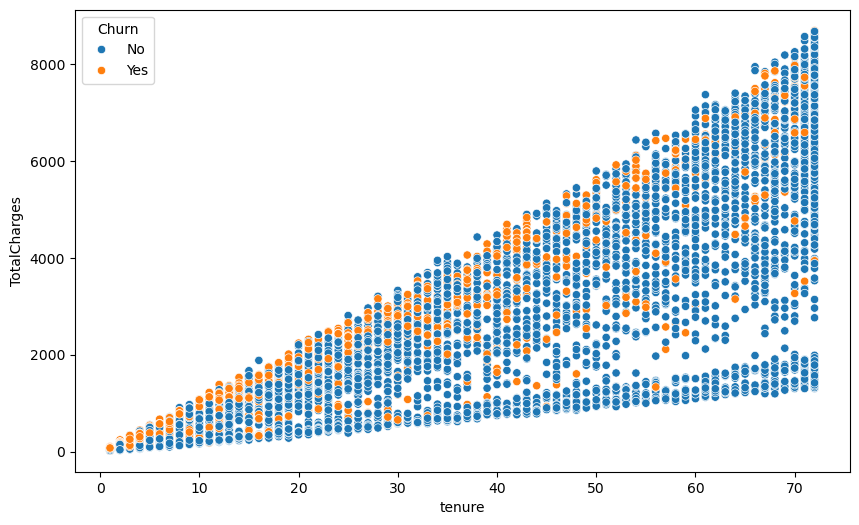

In [132]:
#6. Tenure + Total Charges + Churn
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn')
plt.show()

In [133]:
# After analyzing this visuals the Insight is:
    # Customers who stay with the company for a longer period contribute more revenue over time.
    # Customers with long tenure shows strong loyalty and lower churn probability comparatively.

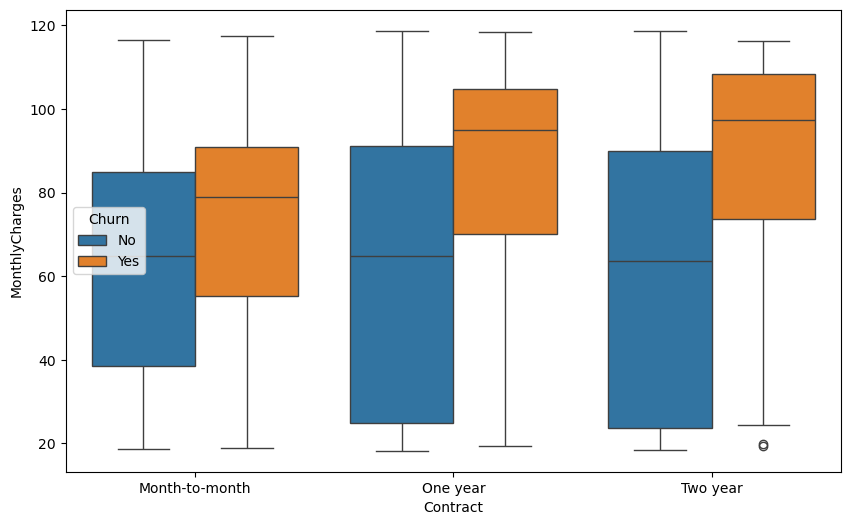

In [134]:
#7. Monthly Charges by Contract and Churn
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Contract', y='MonthlyCharges', hue='Churn')
plt.show()

In [135]:
# After analyzing this visuals the Insight is:
    # Customers who have month-to-month contracts with higher monthly charges are more likely to churn.

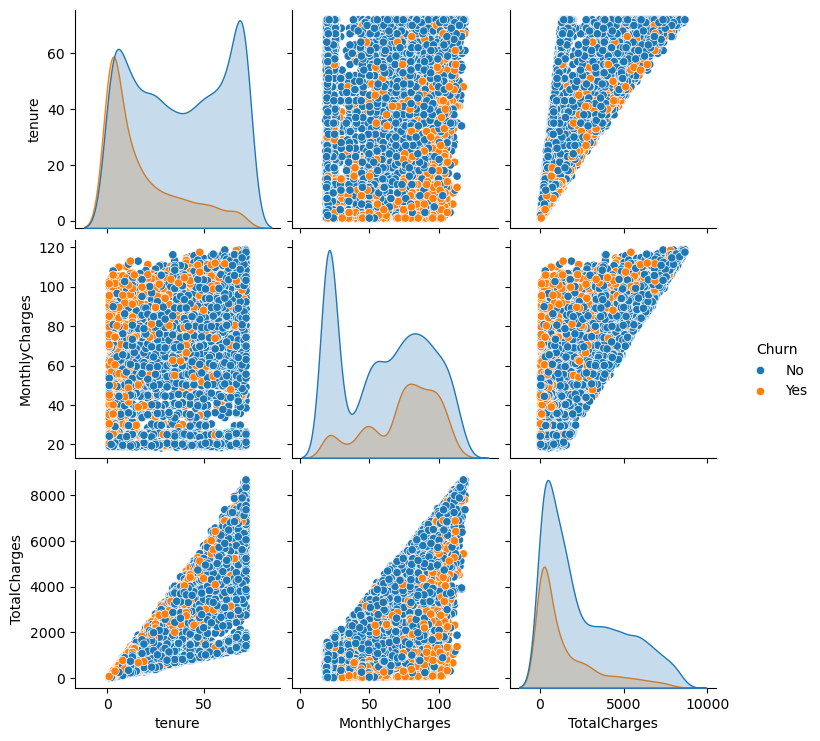

In [136]:
#9. pair plot
sns.pairplot(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']], hue='Churn')
plt.show()

In [137]:
# After analyzing this visuals the Insight is:
    # The Customers who have short tenure are more likely to churn, 
    # whereas long-tenure customers remain loyal to the company.

    # The Customers who paying high monthly charges has high chances of churn,
    # indicating that pricing may influence customer retention.

    # Long-term customers generally generate more lifetime value, 
    # whereas churned customers often exit early without contributing much to overall revenue.

In [138]:
numeric_df = df.select_dtypes(include=['int64','float64'])

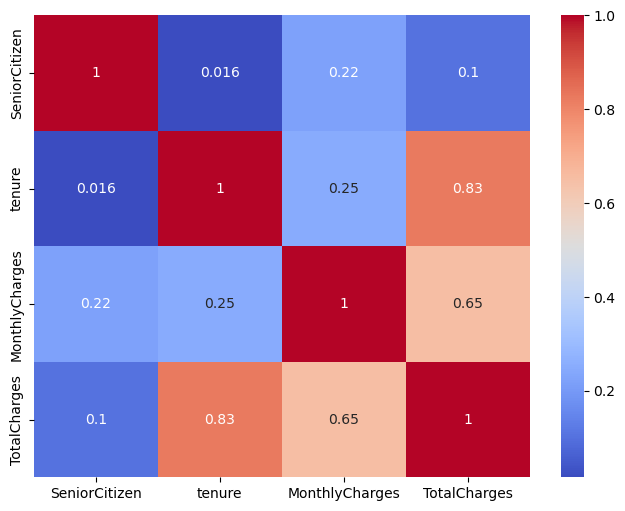

In [139]:
#9. HeatMap Of all the numericals columns
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [140]:
# After analyzing this visuals the Insights is:
    # The correlation of Total Charges with Tenure and Monthly Charges is good Comparatively.

#### Churn Percantage Table 

In [141]:
# Churn Percenatge Table by Contract and Internet Service
churn_table = pd.crosstab([df['Contract'], df['InternetService']], df['Churn'],normalize='index')*100
churn_table.round(2)

Churn                              No    Yes
Contract       InternetService              
Month-to-month DSL              67.78  32.22
               Fiber optic      45.39  54.61
               No               81.11  18.89
One year       DSL              90.70   9.30
               Fiber optic      80.71  19.29
               No               97.52   2.48
Two year       DSL              98.07   1.93
               Fiber optic      92.77   7.23
               No               99.21   0.79

#### Pivot table 

In [142]:
# Pivot table
pivot = pd.pivot_table(df, values='MonthlyCharges', index='Contract', columns='Churn',aggfunc='mean')
pivot

Churn,No,Yes
Contract,,
Month-to-month,61.462635,73.019396
One year,62.540926,85.050904
Two year,60.112798,86.777083


# Phase 3. Feature Engineering

### Drop Unnecessary Column

In [143]:
df.drop('customerID', axis=1, inplace=True)
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


### Encode Target Variable

In [144]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0


# Phase 4. Feature Selection

In [145]:
x = df.drop('Churn', axis=1)
y = df['Churn']

### Identify Numerical & Categorical Columns

In [158]:
# Numeric columns
numeric_cols = x.select_dtypes(include=['int64', 'float64']).columns
# Categorical columns
categorical_cols = x.select_dtypes(include=['object', 'category']).columns

print("Numeric Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numeric Columns:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

Categorical Columns:
Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [161]:
numeric_cols = numeric_cols.drop('SeniorCitizen')
print(numeric_cols)

Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


# Phase 5. train_test_split

In [162]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

# Phase 6. Building Preprocessing pipeline

### Numeric Pipeline

In [163]:
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])

### Categorical pipeline

In [164]:
categorical_transformer = Pipeline(steps=[('encoder',OneHotEncoder(drop='first',handle_unknown='ignore'))])

### Combining Both Pipeline

In [166]:
preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)])

# Phase 7. Models

In [167]:
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

In [169]:
import warnings
warnings.filterwarnings('ignore')

In [170]:
trained_models = {}
results = []

for name, clf in models.items():

    pipe = Pipeline([("preprocessor", preprocessor),("classifier", clf)])
    # Train
    pipe.fit(x_train, y_train)

    # Save Model
    trained_models[name] = pipe

    # Prediction
    pred = pipe.predict(x_test)

    # Metrics
    results.append({"Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred)
    })

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)

# Phase 8. Evaluation Matrix

In [171]:
results_df

,Model,Accuracy,Precision,Recall,F1
0,Logistic,0.799574,0.639394,0.564171,0.599432
2,Random Forest,0.781095,0.614583,0.473262,0.534743
3,KNN,0.756930,0.541026,0.564171,0.552356
1,Decision Tree,0.712154,0.458667,0.459893,0.459279


In [172]:
# So the best Model is Logistic Regression
model_lr = trained_models["Logistic"]

### Confusion Matrix 

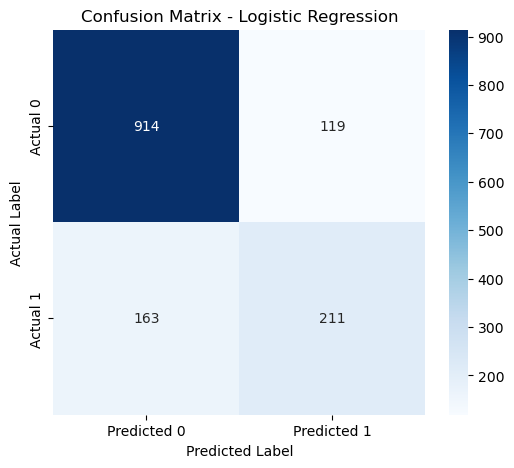

In [173]:
# Prediction
y_pred = model_lr.predict(x_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [174]:
# After analyzing this visuals the Insight is:
    # The Logistic Regression model correctly classified 917 negative and 213 positive instances. 
    # It incorrectly classified 116 negative instances as positive (False Positives) and 161 positive 
    # instances as negative (False Negatives).
    # The model achieved an overall accuracy of approximately 80.3%.

### Roc Curve

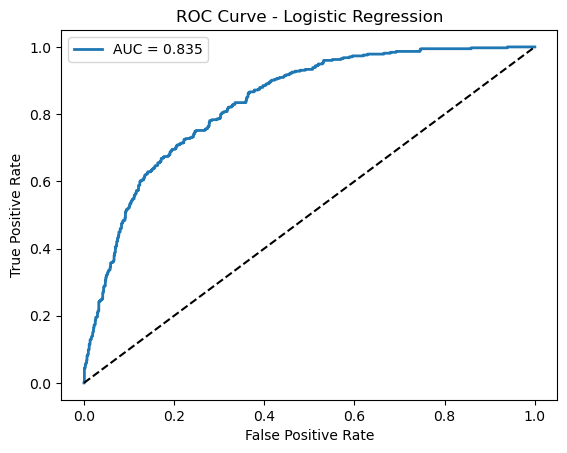

ROC-AUC Score : 0.8348729881814558


In [175]:
# Probability Prediction
y_prob = model_lr.predict_proba(x_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc = roc_auc_score(y_test, y_prob)

# Plot
plt.plot(fpr, tpr,label=f"AUC = {auc:.3f}",linewidth=2)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("ROC-AUC Score :", auc)

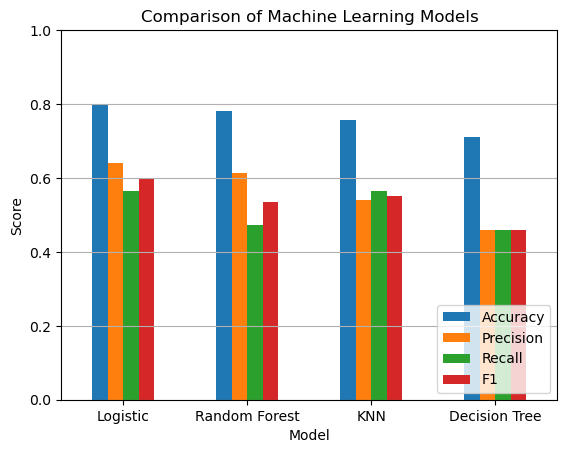

In [176]:
results_df.set_index("Model")[["Accuracy","Precision","Recall","F1"]].plot(kind="bar",)
plt.title("Comparison of Machine Learning Models")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()

In [177]:
# After analyzing this visuals the Insight is:
    # The Logistic Regression is performing best and it is the best Model.

### Applying cross validation 

In [178]:
# 5-Fold Cross Validation
cv_scores = cross_val_score(model_lr, x_train, y_train, cv=5, scoring='accuracy')

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.784      0.81955556 0.80355556 0.79288889 0.81066667]
Mean CV Accuracy: 0.8021333333333333
Standard Deviation: 0.012590884415733887


### Feature Importance

In [179]:
feature_names = model_lr.named_steps["preprocessor"].get_feature_names_out()

In [180]:
coefficients = model_lr.named_steps["classifier"].coef_[0]
importance_df = pd.DataFrame({"Feature": feature_names,
    "Coefficient": coefficients})

importance_df["Absolute Importance"] = importance_df["Coefficient"].abs()

importance_df = importance_df.sort_values(by="Absolute Importance",
    ascending=False)

importance_df.head(10)

,Feature,Coefficient,Absolute Importance
24,cat__Contract_Two year,-1.385103,1.385103
0,num__tenure,-1.340592,1.340592
9,cat__InternetService_Fiber optic,1.117956,1.117956
23,cat__Contract_One year,-0.762149,0.762149
2,num__TotalCharges,0.637234,0.637234
6,cat__PhoneService_Yes,-0.518462,0.518462
1,num__MonthlyCharges,-0.417533,0.417533
27,cat__PaymentMethod_Electronic check,0.387527,0.387527
12,cat__OnlineSecurity_Yes,-0.380358,0.380358
8,cat__MultipleLines_Yes,0.369779,0.369779


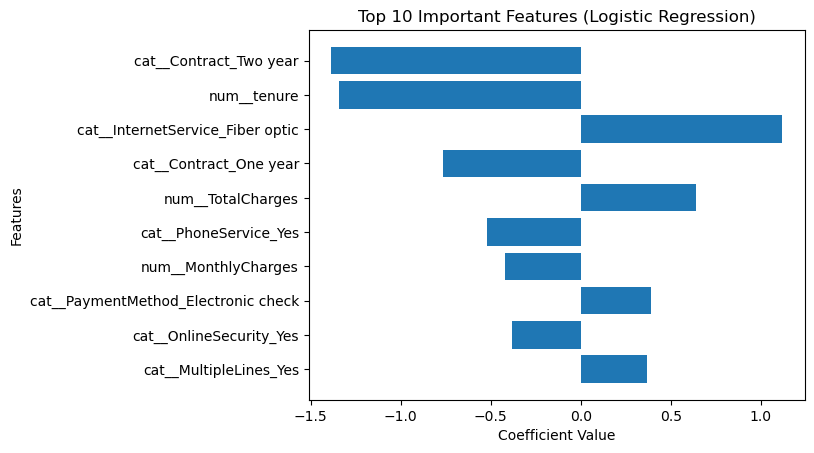

In [181]:
top10 = importance_df.head(10)

plt.barh(top10["Feature"], top10["Coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.title("Top 10 Important Features (Logistic Regression)")
plt.gca().invert_yaxis()
plt.show()

In [182]:
# After analyzing this visuals the Insight is:
    # The Logistic Regression model identified Contract Type, Tenure, and Internet Service (Fiber Optic)
    # as the most influential factors affecting customer churn. 
    # Long-term contracts and higher customer tenure significantly reduce the likelihood of churn, 
    # whereas customers using Fiber Optic internet service and Electronic Check payment method are more likely to churn. 

In [183]:
# Positive cofficient increase churn Probability.
# Negative cofficient decrease churn Probability.

# Phase 9. Hyperparameter Tuning

In [184]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [185]:
param_grid = {
    "classifier__C": [0.01, 0.1, 1, 10, 100],
    "classifier__penalty": ["l2"],
    "classifier__solver": ["lbfgs", "liblinear"]
}

In [186]:
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('encoder',
                                                                                          OneHotEncoder(drop='first',
                                                                                                        handle_unknown='ignore'))]),
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneServi...
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        LogisticRegression(max_iter=1000))]),
             n_jobs=-1,
             param_grid={'classifier__C': [0.01, 0.1, 1, 10, 100],
                         'classifier__penalty': ['l2'],
                         'classifier__solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [187]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__C': 0.1, 'classifier__penalty': 'l2', 'classifier__solver': 'lbfgs'}


In [188]:
best_model = grid_search.best_estimator_

In [189]:
# Tuned Model
y_pred_tuned = best_model.predict(x_test)
y_prob_tuned = best_model.predict_proba(x_test)[:, 1]

print("\n--------- Tuned Logistic Regression ---------")
print("Accuracy :", accuracy_score(y_test, y_pred_tuned))
print("Precision:", precision_score(y_test, y_pred_tuned))
print("Recall   :", recall_score(y_test, y_pred_tuned))
print("F1 Score :", f1_score(y_test, y_pred_tuned))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_tuned))


--------- Tuned Logistic Regression ---------
Accuracy : 0.8002842928216063
Precision: 0.64576802507837
Recall   : 0.5508021390374331
F1 Score : 0.5945165945165946
ROC AUC  : 0.8348703998012125


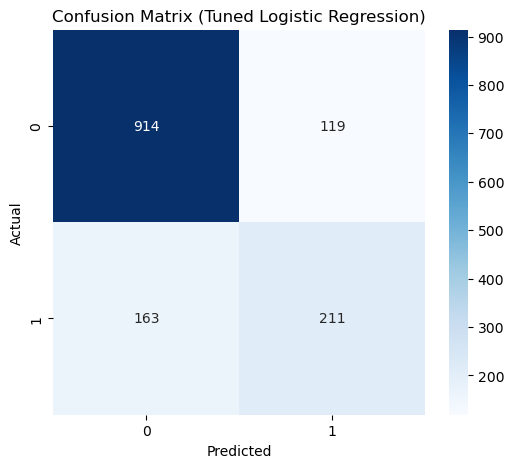

In [190]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Tuned Logistic Regression)")
plt.show()

# Phase 10. Saving our Model

In [191]:
import joblib

In [192]:
# Save the base model
joblib.dump(model_lr, "logistic_regression_base_model.pkl")
print("Base model saved successfully!")

Base model saved successfully!


In [193]:
import sklearn
print(sklearn.__version__)

1.6.1
